### Import Library

In [ ]:
# connect to my drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import needed library
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt # for visualization

### Load and Inspect Data

In [ ]:
# Read in data
df = pd.read_csv("/content/drive/MyDrive/messy_dataset_50.csv")

# Create a copy to work on so that I can always have the source data
df_copy = df.copy()

In [ ]:
df_copy

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,"55,000",Admin
1,2,Bob,twenty,invalidemail.com,NaN,"49,000",IT
2,3,frank,34,NaN,16-02-2020,"69,000",Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,it
4,5,davi,31,davi@mail,2022-12-20,78828,Marketing
5,6,Alic,57,alic@mail.com,2022-03-03,sixty thousand,MARKETING
6,7,Charles,60 years,invalidemail.com,not_a_date,sixty thousand,Admin
7,8,Isabel,57,isabel@mail.com,2022-06-10,NaN,NaN
8,9,Bob,60,bob@mail.com,08-06-2021,sixty thousand,SALES
9,10,Grace,58,invalidemail.com,2021/07/22,NaN,Finance


In [ ]:
# View first five row
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,"55,000",Admin
1,2,Bob,twenty,invalidemail.com,NaN,"49,000",IT
2,3,frank,34,NaN,16-02-2020,"69,000",Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,it
4,5,davi,31,davi@mail,2022-12-20,78828,Marketing


In [ ]:
# View last five row
df_copy.tail()

,ID,Name,Age,Email,Join_Date,Salary,Department
45,46,Henry,29 years,NaN,NaN,53454,finance
46,47,Alice,thirty,alice@@mail.com,NaN,NaN,Finance
47,48,Charle,46,invalidemail.com,not_a_date,sixty thousand,hr
48,49,David,27 years,invalidemail.com,not_a_date,34431,Admin
49,50,Grace,59,grace@mail,2023-05-21,60245,NaN


In [ ]:
# Let's check the dimension
df_copy.shape

(50, 7)

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          50 non-null     int64 
 1   Name        50 non-null     object
 2   Age         45 non-null     object
 3   Email       37 non-null     object
 4   Join_Date   31 non-null     object
 5   Salary      30 non-null     object
 6   Department  39 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.9+ KB


In [ ]:
df_copy.describe()

,ID
count,50.00000
mean,25.50000
std,14.57738
min,1.00000
25%,13.25000
50%,25.50000
75%,37.75000
max,50.00000


In [ ]:
df_copy.describe(include="all")

,ID,Name,Age,Email,Join_Date,Salary,Department
count,50.00000,50,45,37,31,30,39
unique,NaN,27,33,23,27,19,14
top,NaN,Grace,57,invalidemail.com,not_a_date,sixty thousand,Admin
freq,NaN,7,3,8,5,12,7
mean,25.50000,NaN,NaN,NaN,NaN,NaN,NaN
std,14.57738,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN
25%,13.25000,NaN,NaN,NaN,NaN,NaN,NaN
50%,25.50000,NaN,NaN,NaN,NaN,NaN,NaN
75%,37.75000,NaN,NaN,NaN,NaN,NaN,NaN


We can already see from the little inspection of the dataframe that there are missing values (the NaNs), inconsistency, wrong formatting, e.t.c.

### Clean Data

Before we start cleaning proper, let's change any text entry to numbers in the age and salary columns.

* Age text conversion

In [ ]:
# Check unique values in age column
df_copy["Age"].unique()

array(['57', 'twenty', '34', nan, '31', '60 years', '60', '58',
       '50 years', '53 years', '43 years', 'thirty', '55', '40', '54',
       '56', '21', '45 years', '49 years', '22 years', '38 years',
       '30 years', '41 years', '38', '20', '42 years', '36 years', '36',
       '28 years', '26 years', '29 years', '46', '27 years', '59'],
      dtype=object)

In [ ]:
# Lets change "twenty","thirty" to "20", 30 respectively
df_copy["Age"] = df_copy["Age"].str.replace("twenty", "20")
df_copy["Age"] = df_copy["Age"].str.replace("thirty", "30")

In [ ]:
# Let's remove the "years" at the back of the age
df_copy["Age"] = df_copy[ "Age"].str.replace('years', '', regex=False)    # or use this df['Age'] = df['Age'].astype(str).str.replace(r'\D', '', regex=True)

In [ ]:
# Let's see unique value again
df_copy["Age"].unique()

array(['57', '20', '34', nan, '31', '60 ', '60', '58', '50 ', '53 ',
       '43 ', '30', '55', '40', '54', '56', '21', '45 ', '49 ', '22 ',
       '38 ', '30 ', '41 ', '38', '42 ', '36 ', '36', '28 ', '26 ', '29 ',
       '46', '27 ', '59'], dtype=object)

* Salary text conversion

In [ ]:
# Check unique values
df_copy["Salary"].unique()

array(['55,000', '49,000', '69,000', nan, '78828', 'sixty thousand',
       '44,000', '33033', '42606', '76,000', '79209', '61050', '60,000',
       '36890', '76284', '59,000', '41,000', '53454', '34431', '60245'],
      dtype=object)

In [ ]:
# Let's change "sixty thousand" to "60,000"
df_copy["Salary"] = df_copy["Salary"].str.replace("sixty thousand", "60,000")

In [ ]:
# Let's check unique values again
df_copy["Salary"].unique()

array(['55,000', '49,000', '69,000', nan, '78828', '60,000', '44,000',
       '33033', '42606', '76,000', '79209', '61050', '36890', '76284',
       '59,000', '41,000', '53454', '34431', '60245'], dtype=object)

In [ ]:
# View data
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,"55,000",Admin
1,2,Bob,20,invalidemail.com,NaN,"49,000",IT
2,3,frank,34,NaN,16-02-2020,"69,000",Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,it
4,5,davi,31,davi@mail,2022-12-20,78828,Marketing


#### Format Inconsistencies

* Name have inconsistent capitalization and trailing spaces

In [ ]:
# Check unique names
df_copy["Name"].unique()

array(['Grace', 'Bob', 'frank', 'Isabel ', 'davi', 'Alic', 'Charles',
       'Isabe', 'Henry', 'alice', 'grac', 'David', 'david', 'Jack', 'Eve',
       'bob', 'henry', 'Fran', 'Jack ', 'isabel', 'jack', 'Alice',
       'David ', 'Grac', 'Isabel', 'Frank', 'Charle'], dtype=object)

In [ ]:
# Trim spaces using .str.strip()
# Fix casing using str.title()
df_copy['Name'] = df_copy['Name'].str.strip().str.title()

In [ ]:
df_copy["Name"].unique()

array(['Grace', 'Bob', 'Frank', 'Isabel', 'Davi', 'Alic', 'Charles',
       'Isabe', 'Henry', 'Alice', 'Grac', 'David', 'Jack', 'Eve', 'Fran',
       'Charle'], dtype=object)

In [ ]:
# Correct names that are wrongly spelt
correction_map = {
    "grac": "grace",
    "charle": "charlie",
    "alic": "alice",
    "isabe": "isabel",
    "davi": "david"
}

df_copy["Name"] = (
    df_copy["Name"]
    .str.lower()
    .replace(correction_map)
    .str.title()
)


In [ ]:
df_copy["Name"].unique()

array(['Grace', 'Bob', 'Frank', 'Isabel', 'David', 'Alice', 'Charles',
       'Henry', 'Jack', 'Eve', 'Fran', 'Charlie'], dtype=object)

* Department have inconsistent capitalization and abbreviation

In [ ]:
# Check unique department
df_copy["Department"].unique()

array(['Admin', 'IT', 'it', 'Marketing', 'MARKETING', nan, 'SALES',
       'Finance', 'marketing', 'hr', 'ADMIN', 'finance', 'sales', 'admin',
       'Sales'], dtype=object)

In [ ]:
# Trim spaces using .str.strip()
# Fix casing using str.title()
df_copy['Department'] = df_copy['Department'].str.strip().str.title()

In [ ]:
df_copy["Department"].unique()

array(['Admin', 'It', 'Marketing', nan, 'Sales', 'Finance', 'Hr'],
      dtype=object)

In [ ]:
# Change abbreviations to uppercase
df_copy["Department"] = df_copy["Department"].replace({"It": "IT", "Hr": "HR"})

In [ ]:
df_copy["Department"].unique()

array(['Admin', 'IT', 'Marketing', nan, 'Sales', 'Finance', 'HR'],
      dtype=object)

In [ ]:
df_copy["Salary"].unique()

array(['55000', '49000', '69000', nan, '78828', '60000', '44000', '33033',
       '42606', '76000', '79209', '61050', '36890', '76284', '59000',
       '41000', '53454', '34431', '60245'], dtype=object)

* Remove commas and possible trailing spaces in Salary

In [ ]:
# Let's remove the commas
df_copy["Salary"] = df_copy["Salary"].str.replace(",", "")

# Let's remove the trailing spaces
df_copy["Salary"] = df_copy["Salary"].str.strip()

In [ ]:
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,55000,Admin
1,2,Bob,20,invalidemail.com,NaN,49000,IT
2,3,Frank,34,NaN,16-02-2020,69000,Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,IT
4,5,David,31,davi@mail,2022-12-20,78828,Marketing


* Email has inconsistent format

In [ ]:
df_copy["Email"].unique()

array(['grace@mail.com', 'invalidemail.com', nan, 'isabel@mail.com',
       'davi@mail', 'alic@mail.com', 'bob@mail.com', 'isabe@mail.com',
       'grac@mail.com', 'david@mail', 'henry@mail.com', 'eve@mail.com',
       'grace@mail', 'henry@mail', 'fran@@mail.com', 'frank@mail',
       'bob@mail', 'jack@mail.com', 'david@mail.com', 'isabel@@mail.com',
       'charles@@mail.com', 'jack@mail', 'frank@mail.com',
       'alice@@mail.com'], dtype=object)

In [ ]:
# Have consistent format
consistent= {

    # Only do this if you have few correction to make
    "invalidemail.com": "Unknown",
    "davi@mail": "davi@mail.com",
    "bob@mail": "bob@mail.com",
    "david@mail": "david@mail.com",
    "grace@mail": "grace@mail.com",
    "jack@mail": "jack@mail.com",
    "henry@mail": "henry@mail.com",
    "fran@@mail.com": "fran@mail.com",
    "charles@@mail.com": "charles@mail.com",
    "isabel@@mail.com": "isabel@mail.com",
    "alice@@mail.com": "alice@mail.com"

}

# Lets change keep consistency
df_copy["Email"] = df_copy["Email"].replace(consistent)

In [ ]:
df_copy["Email"].unique()

array(['grace@mail.com', 'Unknown', nan, 'isabel@mail.com',
       'davi@mail.com', 'alic@mail.com', 'bob@mail.com', 'isabe@mail.com',
       'grac@mail.com', 'david@mail.com', 'henry@mail.com',
       'eve@mail.com', 'fran@mail.com', 'frank@mail', 'jack@mail.com',
       'charles@mail.com', 'frank@mail.com', 'alice@mail.com'],
      dtype=object)

In [ ]:
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,18-08-2022,55000,Admin
1,2,Bob,20,Unknown,NaN,49000,IT
2,3,Frank,34,NaN,16-02-2020,69000,Admin
3,4,Isabel,NaN,isabel@mail.com,08-10-2020,NaN,IT
4,5,David,31,davi@mail.com,2022-12-20,78828,Marketing


#### Fix Data Types

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          50 non-null     int64 
 1   Name        50 non-null     object
 2   Age         45 non-null     object
 3   Email       37 non-null     object
 4   Join_Date   31 non-null     object
 5   Salary      30 non-null     object
 6   Department  39 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.9+ KB


In [ ]:
# Convert Age
df_copy['Age'] = pd.to_numeric(df_copy['Age'], errors='coerce')

# Convert Salary
df_copy['Salary'] = pd.to_numeric(df_copy['Salary'], errors='coerce')

# Convert Join_Date to datetime
def parse_date(value):
    """
    A function that handles any data format
    present in the Join_Date column
    """
    # If already a datetime, return it
    if isinstance(value, pd.Timestamp):
        return value

    # Handle missing values
    if pd.isna(value):
        return pd.NaT

    # Try parsing string dates
    value = str(value).strip()

    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%Y/%m/%d", "%m/%d/%Y"):
        try:
            return datetime.strptime(value, fmt)
        except ValueError:
            continue

    # If all parsing fails
    return pd.NaT

# Let's call in the function on the Join_Date column
df_copy["Join_Date"] = df_copy["Join_Date"].apply(parse_date)


In [ ]:
# Check info again
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          50 non-null     int64         
 1   Name        50 non-null     object        
 2   Age         45 non-null     float64       
 3   Email       37 non-null     object        
 4   Join_Date   26 non-null     datetime64[ns]
 5   Salary      30 non-null     float64       
 6   Department  39 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 2.9+ KB


We can see the Data type of Age, Salary, Join_Date columns has changed from object to float.

In [ ]:
# view dataframe
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57.0,grace@mail.com,2022-08-18,55000.0,Admin
1,2,Bob,20.0,Unknown,NaT,49000.0,IT
2,3,Frank,34.0,NaN,2020-02-16,69000.0,Admin
3,4,Isabel,NaN,isabel@mail.com,2020-10-08,NaN,IT
4,5,David,31.0,davi@mail.com,2022-12-20,78828.0,Marketing


#### Handle Missing Value

In [ ]:
# First is to replace Null or Nan string value in the data with an actual NAN recognized by Python using np.nan
df_copy.replace(["NULL", "NaN", "nan", "None", "NAN", "NaT"], np.nan, inplace=True)

In [ ]:
# Check how many missing value using isna or isnull
df_copy.isna().sum()

,0
ID,0
Name,0
Age,5
Email,13
Join_Date,24
Salary,20
Department,11


As we can see above 5 different columns contains missing value. Age column has 5 missing values, Email has 13, Join_Date has 19, Salary has 20, and Department column has 11 missing values

In [ ]:
# Let's decide how to handle missing values

# We drop critical ones
df_copy.dropna(subset=["ID", "Name", "Email", "Join_Date"], inplace=True)     # These are the critical ones because we can't just impute any Name or Email

# Impute non-critical ones

# Let's fill in the missing value with mean age
df_copy["Age"] = df_copy["Age"].fillna(round(df_copy["Age"].mean()))

# Let's fill in the missing value with mean salary
df_copy["Salary"] = df_copy["Salary"].fillna(round(df_copy["Salary"].mean()))

# Let's fill in the missing value for department with Unknown
df_copy["Department"] = df_copy["Department"].fillna('Unknown')

In [ ]:
# Check for missing value again
df_copy.isna().sum()

,0
ID,0
Name,0
Age,0
Email,0
Join_Date,0
Salary,0
Department,0


In [ ]:
# Convert age to int after filling missing value
df_copy["Age"] = df_copy["Age"].astype(int)

In [ ]:
# View the first five row again
df_copy.head()

,ID,Name,Age,Email,Join_Date,Salary,Department
0,1,Grace,57,grace@mail.com,2022-08-18,55000.0,Admin
3,4,Isabel,44,isabel@mail.com,2020-10-08,59764.0,IT
4,5,David,31,davi@mail.com,2022-12-20,78828.0,Marketing
5,6,Alice,57,alic@mail.com,2022-03-03,60000.0,Marketing
7,8,Isabel,57,isabel@mail.com,2022-06-10,59764.0,Unknown


In [ ]:
# Check the dimension again
df_copy.shape

(21, 7)

#### Duplicate Enteries

In [ ]:
# Check for duplicates
print(df_copy.duplicated().sum())

0


The output of 0 above tells us that there are no duplicates in the data.

In [ ]:
# If duplicates is found in a dataset, the code to drop them follows the format below
# df_copy.drop_duplicates(subset=['ID'], keep='first', inplace=True)

#### Check for Outliers

In [ ]:
df_copy.describe()

,ID,Age,Join_Date,Salary
count,21.000000,21.000000,21,21.000000
mean,21.095238,44.142857,2021-12-08 06:51:25.714285824,59764.285714
min,1.000000,21.000000,2020-02-14 00:00:00,41000.000000
25%,9.000000,36.000000,2021-03-28 00:00:00,59764.000000
50%,18.000000,44.000000,2022-03-03 00:00:00,59764.000000
75%,35.000000,57.000000,2022-11-16 00:00:00,60000.000000
max,50.000000,60.000000,2023-11-27 00:00:00,79209.000000
std,15.059564,12.539082,NaN,9811.910640


Taking a careful look at the summary statistics we can see that the mean, median of age and salary have the same value with just slight difference. This suggest to us that there is no outlier in the data. Let's cofirm that with the IQR (Inter-Quartile Range) method.

In [ ]:
# Use IQR(Interquatile range) to detect outlier
Q1 = df_copy['Age'].quantile(0.25)
Q3 = df_copy['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['Age'] < lower_bound) | (df_copy['Age'] > upper_bound)]


In [ ]:
# View outliers if any
print(outliers)

Empty DataFrame
Columns: [ID, Name, Age, Email, Join_Date, Salary, Department]
Index: []


Having an empty dataframe output tells us that there is no outlier in the dataset. Let's proceed to use the visual method of boxplot

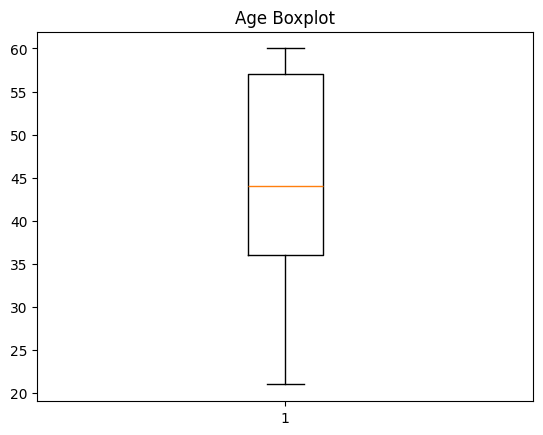

In [ ]:
# Visual confirmation
plt.boxplot(df_copy['Age'])
plt.title("Age Boxplot")
plt.show()


The boxplot confirms that the data does not contain an outlier as there is no dot outside the whiskers.

#### Save Cleaned Data

The data cleaning is done. The messy dataset is now clean so let's save it in our work directory

In [ ]:
df_copy.to_csv("cleaned_data.csv", index=False)